# EPIC Institute of Technology
## Data Science Mid-term Exam

# Data

gender.csv

### Objective features:

Age
Height
Weight
Sex (gender)
Measurement results:

Upper and lower blood pressure (ap_hi, ap_lo)
Cholesterol (cholesterol)
Glucose (glucose)

### Subjective features (according to patients):

Smoking (smoke)
Drinking alcohol (alco)
Physical activity (active)
Target sign (which will be interesting to predict):
The presence of cardiovascular diseases according to the results of a classic medical examination (cardio)

Age is given in days.
The values of cholesterol and glucose are represented by one of three classes: normal, above normal, significantly above normal.
The values of subjective features are binary.

All figures are given at the time of inspection.

## Task 0
### Import necesssary libraries and read the data. Note that data is separated with semicolon ';'

In [114]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df=pd.read_csv('gender.csv',delimiter=';')
pd.read_csv('gender.csv',delimiter=';')[:5]


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Task 1 (2 points)
### Exploratory Data Analysis (EDA): Create Descriptive Graphs for Initial Data Exploration.
- Histograms for Age, Height, Weight, ap_hi, and ap_lo to visualize the distribution.
- Bar charts for gender, smoke, alco, and active to show the count of each category.
- Any other graphs that you find useful

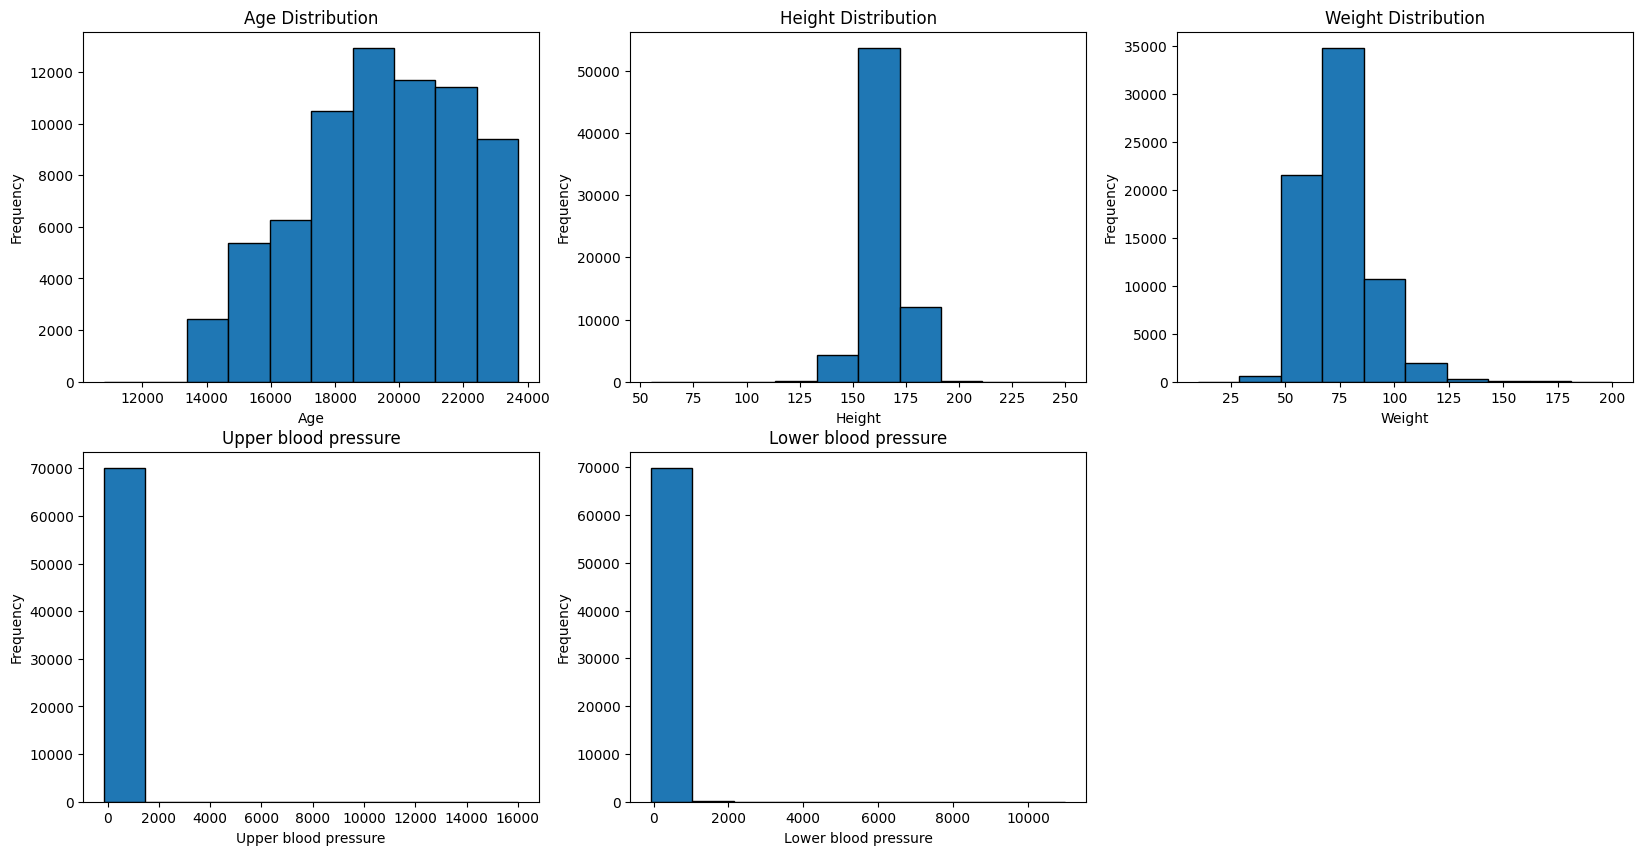

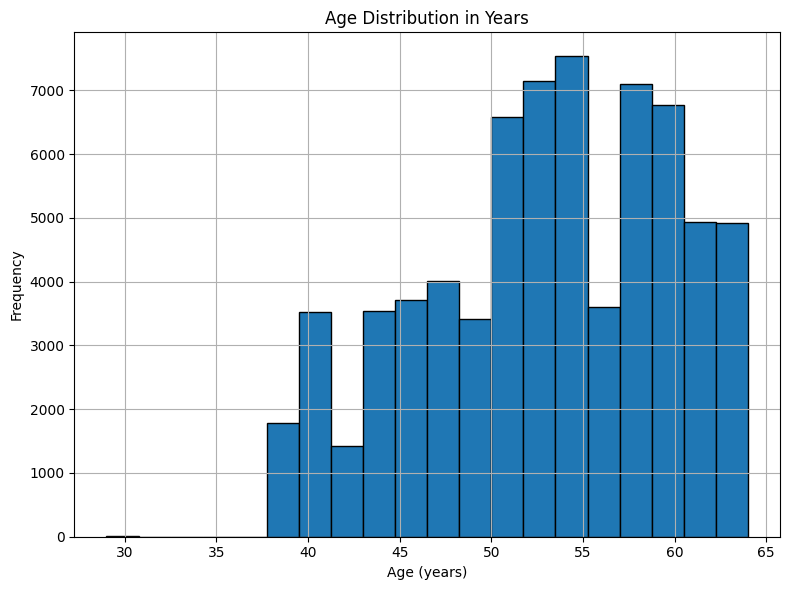

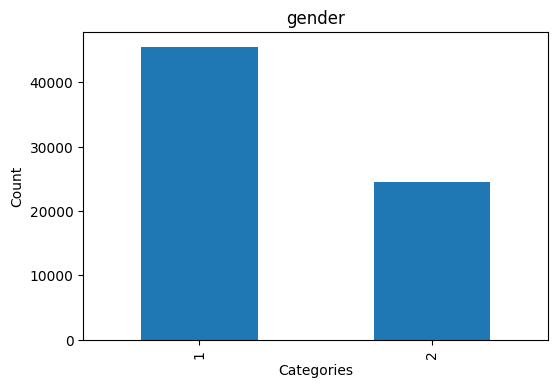

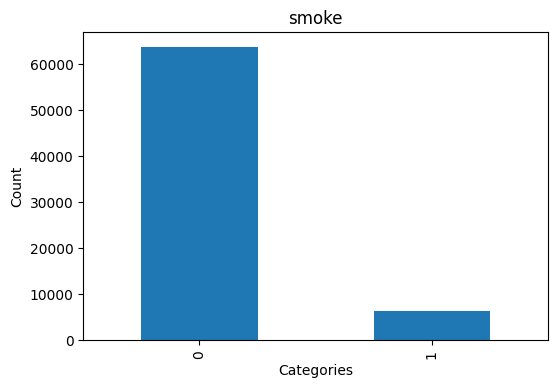

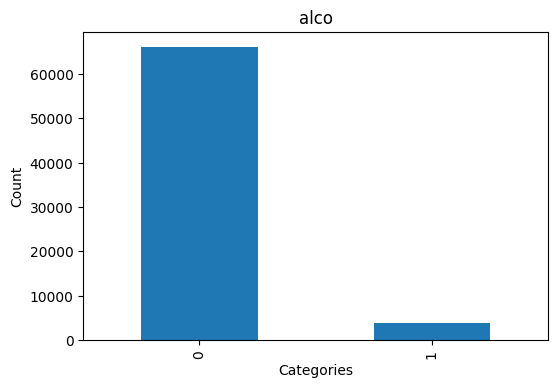

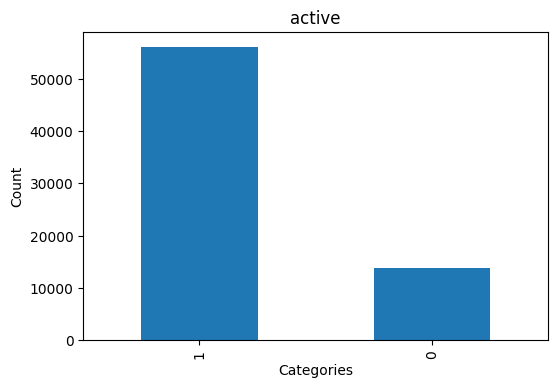

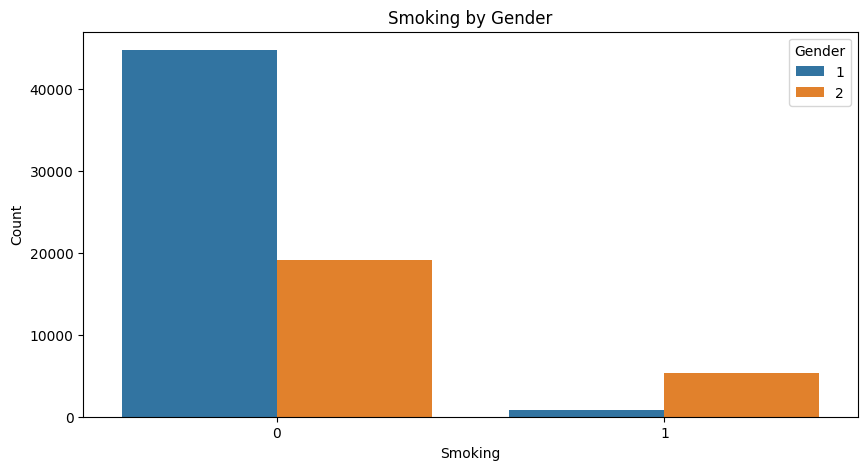

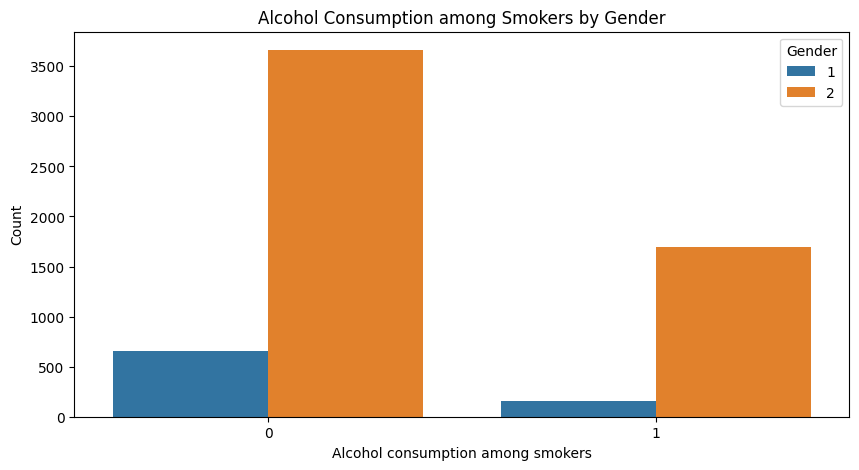

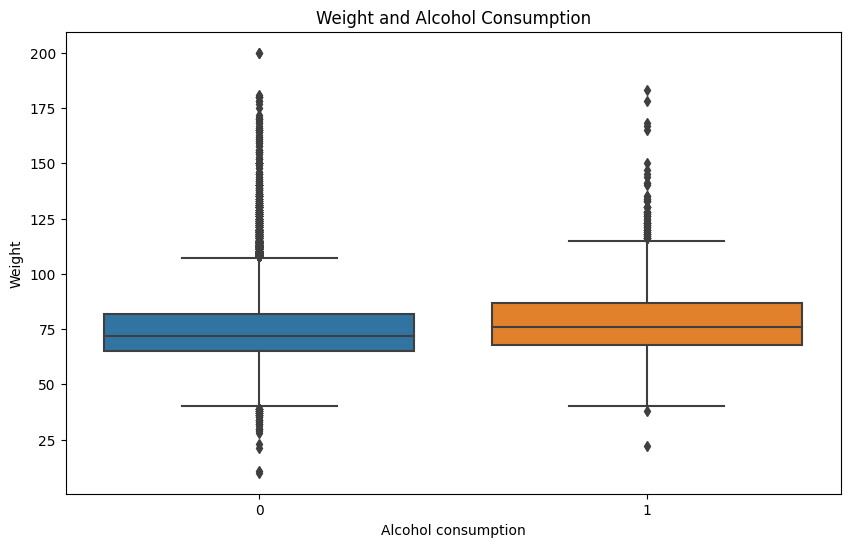

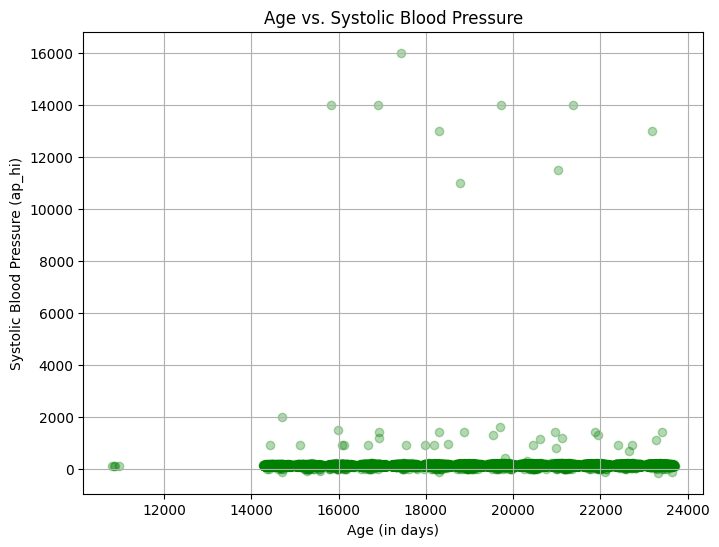

(70000, 14)


In [115]:
import pandas as pd
import matplotlib.pyplot as plt


# Гистограммы
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.hist(df['age'], edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.subplot(2, 3, 2)
plt.hist(df['height'], edgecolor='black')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')

plt.subplot(2, 3, 3)
plt.hist(df['weight'], edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Weight Distribution')

plt.subplot(2, 3, 4)
plt.hist(df['ap_hi'], edgecolor='black')
plt.xlabel('Upper blood pressure')
plt.ylabel('Frequency')
plt.title('Upper blood pressure')

plt.subplot(2, 3, 5)
plt.hist(df['ap_lo'], edgecolor='black')
plt.xlabel('Lower blood pressure')
plt.ylabel('Frequency')
plt.title('Lower blood pressure')

plt.figure(figsize=(8, 6))
df['age_years'] = df['age'] // 365
df['age_years'].plot(kind='hist', bins=20, edgecolor='black')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Age Distribution in Years')
plt.grid(True)

plt.tight_layout()
plt.show()



# Столбчатые диаграммы
categorical_cols = ['gender', 'smoke', 'alco', 'active']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar')
    plt.title(col)
    plt.xlabel('Categories')
    plt.ylabel('Count')
    plt.xticks(range(len(value_counts)), value_counts.index)  # Устанавливаем подписи категорий
    plt.show()

# Другие полезные графики
import seaborn as sns


#Зависимость курения и пола
plt.figure(figsize=(10, 5))
sns.countplot(x='smoke', hue='gender', data=df)
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.title('Smoking by Gender')
plt.legend(title='Gender')
plt.show()

# Потребление алкоголя среди курильщиков в зависимости от пола
plt.figure(figsize=(10, 5))
sns.countplot(x='alco', hue='gender', data=df[df['smoke'] == 1])
plt.xlabel('Alcohol consumption among smokers')
plt.ylabel('Count')
plt.title('Alcohol Consumption among Smokers by Gender')
plt.legend(title='Gender')
plt.show()

#Связь между весом и употреблением алкоголя
plt.figure(figsize=(10, 6))
sns.boxplot(x='alco', y='weight', data=df)
plt.xlabel('Alcohol consumption')
plt.ylabel('Weight')
plt.title('Weight and Alcohol Consumption')
plt.show()



# ГРафик зависимости возраста и верхнего артериального давления
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['ap_hi'], alpha=0.3, color='green')
plt.xlabel('Age (in days)')
plt.ylabel('Systolic Blood Pressure (ap_hi)')
plt.title('Age vs. Systolic Blood Pressure')
plt.grid(True)
plt.show()


print(df.shape)

## Task 2 (1 point)
### Data Cleaning: Identify and Remove Outliers in Non-Binary Features
- Identify and remove 5% (both bottom and top) of outliers for non-binary features.
- Identify and remove other inappropriate data (such as negative values)

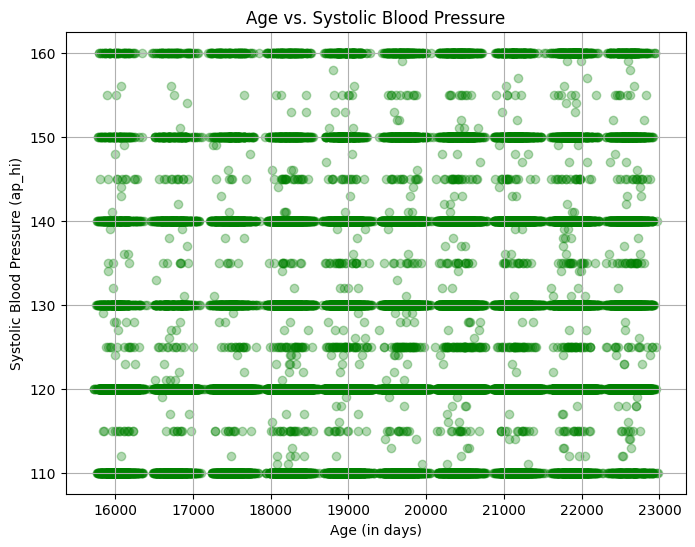

(39140, 14)


In [116]:
# Поделю данные на бин и нет

data_types = df.dtypes

# Определение числовых столбцов(хоть и при просмотре датасета видно, что тут только числовые)
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# небинарные
non_bin = [col for col in numeric_columns if df[col].nunique() > 2]

# бинарные
bin= [col for col in numeric_columns if df[col].nunique() == 2]

for column in non_bin:
    l = df[column].quantile(0.05)
    u = df[column].quantile(0.95)
    df = df[(df[column] >= l) & (df[column] <= u)]

#удаление отрицательных значений
for column in numeric_columns:
    df = df[df[column] >= 0]

#интересно взглянуть на этот график теперь)
# ГРафик зависимости возраста и верхнего артериального давления
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['ap_hi'], alpha=0.3, color='green')
plt.xlabel('Age (in days)')
plt.ylabel('Systolic Blood Pressure (ap_hi)')
plt.title('Age vs. Systolic Blood Pressure')
plt.grid(True)
plt.show()
print(df.shape)

## Task 3 (1 point)
### Confidence Intervals: Calculate Confidence Intervals for Height and Weight
- After cleaning, calculate the 95% confidence interval for height and 99.7% for weight.

In [117]:

from scipy import stats


#уберу Nan если они тут есть
clean_data = df.dropna(subset=['height', 'weight'])

#вычисление доверительного интервала для высоты  ( 95%)
height_ci = stats.t.interval(0.95, len(clean_data['height']) - 1,
                             loc=clean_data['height'].mean(),
                             scale=stats.sem(clean_data['height']))

#вычисление доверительного интервала для веса    (99.7%)
weight_ci = stats.t.interval(0.997, len(clean_data['weight']) - 1,
                             loc=clean_data['weight'].mean(),
                             scale=stats.sem(clean_data['weight']))

print(f"95% confidence interval for height: {height_ci}")
print(f"99.7% confidence interval for weight: {weight_ci}")




95% confidence interval for height: (164.64543667319825, 164.7684621515335)
99.7% confidence interval for weight: (73.53249708733472, 73.84731691368722)


## Task 4 (1 point)
### Data Transformation - One-Hot Encoding:
- Apply one-hot encoding for cholesterol and glucose.

In [118]:
# Проверка на наличие NaN
missing_values = df.isna().sum()
print(missing_values)
print(df.shape)

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64
(39140, 14)


In [119]:
new_df = pd.get_dummies(df, columns=['cholesterol', 'gluc'])


print(new_df.head())


        id    age  gender  height  weight  ap_hi  ap_lo  smoke  alco  active  \
3500  4955  22529       2     176    68.0    110     70      1     0       1   
3502  4960  17003       1     159    71.0    120     80      0     0       1   
3504  4963  21183       1     164    93.0    150    100      0     0       1   
3506  4966  16925       2     175    72.0    120     80      0     0       1   
3508  4968  21143       2     166    75.0    120     80      0     0       1   

      cardio  age_years  cholesterol_1  cholesterol_2  cholesterol_3  gluc_1  \
3500       0         61              1              0              0       1   
3502       0         46              1              0              0       1   
3504       1         58              0              1              0       1   
3506       0         46              1              0              0       1   
3508       0         57              1              0              0       0   

      gluc_2  gluc_3  
3500       0   

## Task 5 (2 points)
### Hypothesis Testing - T-Test: Investigate Gender Differences in Average Height
- Before conducting the two-tailed t-test to compare the average height between men and women, check for significant differences in variance between the two groups
- If the variance differs significantly, use Welch's t-test

In [120]:

from scipy.stats import levene

#росты м и ж
male_heights = df[df['gender'] == 1]['height']
female_heights = df[df['gender'] == 2]['height']

#проверка дисперсий с помощью теста Левена
statistic, p_value = levene(male_heights, female_heights)

# Отображение результатов
print(f"Leven Test Statistics: {statistic}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Significant differences in variance")
else:
    print("There are no significant differences in variance")



Leven Test Statistics: 175.7740913948281
p-value: 4.949855294246517e-40
Significant differences in variance


In [121]:
#т.к. выяснили в ячейке выше, что дисперсия значительно отличается, то использую t-критерий Уэлча

from scipy.stats import ttest_ind
t_statistic, t_p_value = ttest_ind(male_heights, female_heights, equal_var=False)
#вывод результатов t-теста Уэлча
print(f"Welch's t-test t-statistics: {t_statistic}")
print(f"p-values: {t_p_value}")

if t_p_value < 0.05:
    print("Significant differences in average values of heights")
else:
    print("There are no significant differences in the average values of heights")


Welch's t-test t-statistics: -110.59577925895418
p-values: 0.0
Significant differences in average values of heights


## Task 6 (3 points)
### Model building: Build and Optimize Model for Cardiovascular Disease Prediction
- Select a model of your choice and predict Cardiovascular Disease
- Try different hyperparameters to optimize the model
- Calculate model accuracy

Точность модели логистической регрессии: 0.6849770056208483


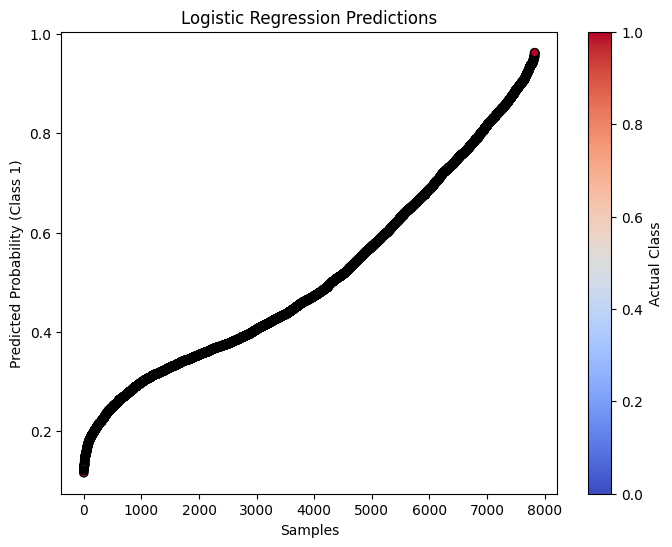

In [122]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



df['smoke_drink'] = ((df['smoke'] == 1) | (df['alco'] == 1)).astype(int)
df['smoke_drink_ac'] = ((df['smoke'] == 1) | (df['alco'] == 1)| (df['active'] == 1)).astype(int)
#категор данные
a=['age','gender','smoke','alco','active']

X = df.drop('cardio', axis=1)

y = df['cardio']

X_encoded = pd.get_dummies(X, columns=a, drop_first=True)

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


accuracy = model.score(X_test, y_test)
print(f"Точность модели логистической регрессии: {accuracy}")
y_pred_proba = model.predict_proba(X_test)[:, 1]


sorted_indices = np.argsort(y_pred_proba)
y_test_sorted = y_test.iloc[sorted_indices]
y_pred_proba_sorted = y_pred_proba[sorted_indices]

# Построение графика
plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_pred_proba)), y_pred_proba_sorted, c=y_test_sorted, cmap='coolwarm', edgecolors='k')
plt.xlabel('Samples')
plt.ylabel('Predicted Probability (Class 1)')
plt.title('Logistic Regression Predictions')
plt.colorbar(label='Actual Class')
plt.show()